In [2]:
# My plan is, to do the EDA and then feature engineering and then clustering and then visualize. Here, I can look at the data and find out stuff.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
flights = pd.read_csv('raw_data/flights_filtered.csv')
hotels = pd.read_csv('raw_data/hotels_filtered.csv')
users = pd.read_csv('raw_data/Users_filtered.csv')
sessions= pd.read_csv('raw_data/Sessions_filtered.csv')

In [5]:
sessions.head()

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
0,167852-c8b94dadc94c4f6889c506635eabcae5,167852,NaN,2022-05-03 08:20:00,2022-05-03 08:21:15,True,True,0.05,0.10,False,False,10,False
1,101961-90b0b37c3d3d4676b2a62d6485e02935,101961,NaN,2022-05-09 18:14:00,2022-05-09 18:17:08,False,False,NaN,NaN,False,False,25,False
2,174997-8a2be403095348558385433f288d6440,174997,174997-a7c3a96620594e849a2345ac4e0bd45d,2022-05-10 20:16:00,2022-05-10 20:17:50,False,True,NaN,0.05,True,False,15,False
3,106907-4c1f7d4d0a6b4d7f874ab0012f5673e7,106907,NaN,2022-05-13 14:25:00,2022-05-13 14:29:14,False,False,NaN,NaN,False,False,34,False
4,181157-7279cbcf6b5f4396b2b22cd59741e7c3,181157,181157-259acaefcd924050bd6640f049eded1a,2022-05-15 20:13:00,2022-05-15 20:16:04,False,False,NaN,NaN,True,True,25,False


In [6]:
sessions[~(~sessions[["flight_discount_amount", "hotel_discount_amount"]].isna().values == sessions[["flight_discount", "hotel_discount"]].values).all(axis=1)]

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
23906,101486-46912e06b8f94b949f46af20eb097f8f,101486,101486-29a51199b1a748da8c45d3d2fc9c691a,2022-03-26 20:08:22,2022-03-26 22:08:22,True,True,NaN,NaN,True,True,156,True
23907,118043-e476985728a741d7a96ea1dcf55963e6,118043,118043-2c1b2e17eb1147e184b00be13725d0fd,2022-04-22 09:38:27,2022-04-22 10:04:44.411729,True,True,NaN,NaN,True,True,26,True
23908,153982-0a2c4b9c37594cca8019068acedd878a,153982,153982-5ee3beaabece462ba68982ef4f8e3a23,2022-07-08 13:15:40,2022-07-08 14:20:35.612564,True,True,NaN,NaN,True,True,64,True
23909,174997-d37e4081489646fc891296f5e21b96f1,174997,174997-a7c3a96620594e849a2345ac4e0bd45d,2023-01-05 20:17:50,2023-01-05 22:17:50,True,True,NaN,NaN,True,True,155,True
23910,181157-4689176bf8e2444f928c77739c75c713,181157,181157-259acaefcd924050bd6640f049eded1a,2022-05-23 20:16:04,2022-05-23 22:16:04,True,True,NaN,NaN,True,True,200,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48673,694265-74b2a86e73854afea04cd84b1a1d10e3,694265,694265-442d6499b511481786add276f620d4fc,2023-07-26 21:37:49,2023-07-26 22:30:14.467636,True,True,NaN,NaN,True,True,52,True
48674,589228-c82de5b13d8d4739aeb90e2ca924d2e0,589228,589228-7cbd8bd73eed4c549a0074919e71fdc8,2023-07-20 21:01:17,2023-07-20 21:45:04.905844,True,True,NaN,NaN,True,True,43,True
48675,671151-fa865fb0bf8249aeb164408b470322d2,671151,671151-a25acb9062764a168fbd4286d15d57fd,2023-07-24 17:45:47,2023-07-24 18:09:14.839854,True,True,NaN,NaN,True,True,23,True
48676,609393-17fa2042385e48faac6ab20586749340,609393,609393-b92d487037ec447db1e3ddf977709a52,2023-07-21 21:02:05,2023-07-21 21:27:18.179946,True,True,NaN,NaN,True,True,25,True


- deleting columns hotel/flight_discount, because the information is already in the amount section?
→ Error in the data: there are rows, that say, there are discounts, but there is no amount
→ assumption: error in amount, not in True/False column. So I am filling in the False NaN values with the mean # TODO

In [7]:
sessions.info()

<class 'pandas.DataFrame'>
RangeIndex: 48683 entries, 0 to 48682
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   session_id              48683 non-null  str    
 1   user_id                 48683 non-null  int64  
 2   trip_id                 16778 non-null  str    
 3   session_start           48683 non-null  str    
 4   session_end             48683 non-null  str    
 5   flight_discount         48683 non-null  bool   
 6   hotel_discount          48683 non-null  bool   
 7   flight_discount_amount  8170 non-null   float64
 8   hotel_discount_amount   6183 non-null   float64
 9   flight_booked           48683 non-null  bool   
 10  hotel_booked            48683 non-null  bool   
 11  page_clicks             48683 non-null  int64  
 12  cancellation            48683 non-null  bool   
dtypes: bool(5), float64(2), int64(2), str(4)
memory usage: 3.2 MB


Dtypes seem correct, but not session start/end. I would change that #TODO

In [8]:
sessions[["flight_discount_amount", "hotel_discount_amount"]].mean()

flight_discount_amount    0.139553
hotel_discount_amount     0.112065
dtype: float64

In [9]:
#clicks per customer per session or per booking
#trips per user
# how many sessions per trip per user

<Axes: >

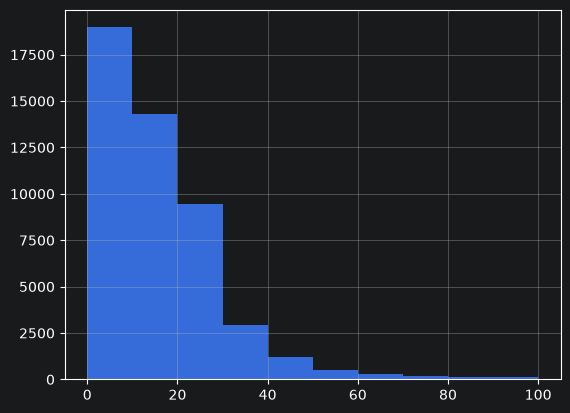

In [10]:
sessions['page_clicks'].hist(range=[0,100])

with a few hundred outliers above 100

In [11]:
# sessions per trip per user
sessions.groupby(['user_id','trip_id'])['session_id'].count().sort_values(ascending=False)

user_id  trip_id                                
489949   489949-f200d9372a324acdbf7aada5aa0b6e0b    2
516287   516287-c0b46e14564846a6924ee99a3f4ccbc6    2
466723   466723-74f4e79cac114a0885abe1e86ece97b1    2
357737   357737-996df5d1f37a4315be6c01d6768d3a7f    2
534703   534703-adcab62a242a48bd965a8db842038768    2
                                                   ..
777846   777846-1098b773e50b49dc96ddea37941732d4    1
         777846-22f7345a386745dfac483265569291d5    1
780167   780167-006179ba70de4a6f8ff8d2e0d42b0688    1
         780167-2bd7f93604a349b79f8721f3a6c72f31    1
101486   101486-1015905607d74b15954bfd4ac7029ef3    1
Name: session_id, Length: 16164, dtype: int64

# hotels

In [12]:
hotels.head()

,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd
0,228872-47e5bd5e323748bb85e3a0944e6b6ad3,Banyan Tree - phoenix,4,1,2022-07-19 10:45:34.065,2022-07-23 11:00:00,107
1,440212-96a28edb355f4656b9c3ce40dc380339,Radisson - baltimore,1,2,2022-12-05 09:34:32.7,2022-12-06 11:00:00,115
2,446933-4273e6639af84810a800fa552fc8bdfd,Fairmont - new york,6,1,2022-12-14 11:00:00,2022-12-20 11:00:00,167
3,478760-840b3de1be6748bebe15747d340b556d,Banyan Tree - hamilton,5,2,2022-12-22 11:00:00,2022-12-27 11:00:00,174
4,443652-134aa9d023a54f63854c7e455754ba16,Shangri-La - austin,2,3,2022-12-30 13:33:33.345,2023-01-02 11:00:00,336


In [13]:
#assumption: hotel per room usd is also per night
#check out time is always 11 o'clock, but check In time is personalized
#nights isn't always right -> -2 and 0 nights

In [14]:
#hotels['nights_new']=
hotels['check_in_time']=pd.to_datetime(hotels['check_in_time'], format='mixed')
hotels['check_out_time']=pd.to_datetime(hotels['check_out_time'], format='mixed')

In [15]:
hotels["checkin_weekday"] = hotels["check_in_time"].dt.day_of_week
hotels["checkout_weekday"] = hotels["check_out_time"].dt.day_of_week

In [16]:
hotels.head()

,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd,checkin_weekday,checkout_weekday
0,228872-47e5bd5e323748bb85e3a0944e6b6ad3,Banyan Tree - phoenix,4,1,2022-07-19 10:45:34.065,2022-07-23 11:00:00,107,1,5
1,440212-96a28edb355f4656b9c3ce40dc380339,Radisson - baltimore,1,2,2022-12-05 09:34:32.700,2022-12-06 11:00:00,115,0,1
2,446933-4273e6639af84810a800fa552fc8bdfd,Fairmont - new york,6,1,2022-12-14 11:00:00.000,2022-12-20 11:00:00,167,2,1
3,478760-840b3de1be6748bebe15747d340b556d,Banyan Tree - hamilton,5,2,2022-12-22 11:00:00.000,2022-12-27 11:00:00,174,3,1
4,443652-134aa9d023a54f63854c7e455754ba16,Shangri-La - austin,2,3,2022-12-30 13:33:33.345,2023-01-02 11:00:00,336,4,0


In [17]:
hotels["nights_new"] = (pd.to_datetime(hotels["check_out_time"].dt.date) - pd.to_datetime(hotels["check_in_time"].dt.date)).dt.days

In [18]:
hotels['nights_new'].value_counts()

nights_new
 2     3166
 3     2569
 4     1834
 1     1765
 5     1232
 6      844
 7      592
 8      412
 0      401
 9      345
 10     255
 11     215
 12     177
 13     104
 14      95
 15      76
 16      56
 17      43
 18      41
-1       29
 20      24
 21      19
 22      14
 19      10
 23       8
 24       6
 25       5
 26       5
 29       4
 28       4
 27       4
 34       3
 30       3
 35       2
 31       2
 32       2
 38       2
 36       1
 33       1
 42       1
 40       1
 47       1
 43       1
Name: count, dtype: int64

In [19]:
# -1 has to be an error in the data -> deleting those 29 rows:
hotels = hotels[hotels['nights_new'] > 0]

In [20]:
#overall costs for the hotel
hotels['overall_costs']= hotels['hotel_per_room_usd']* hotels['nights_new']*hotels['rooms']

In [21]:
#dropping old nights column
hotels.drop('nights',axis=1, inplace=True)

<Axes: xlabel='nights_new', ylabel='Count'>

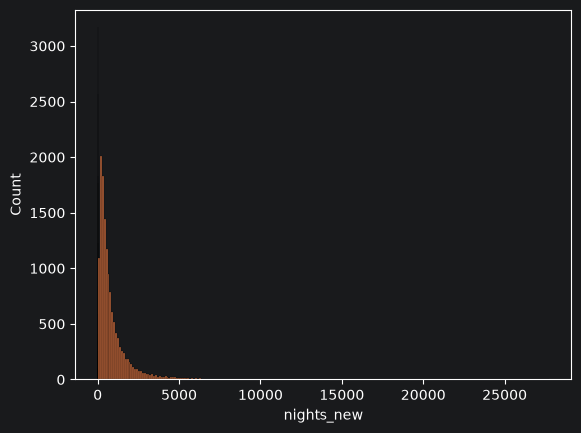

In [24]:
sns.histplot(hotels,x="nights_new")

<Axes: xlabel='overall_costs', ylabel='Count'>

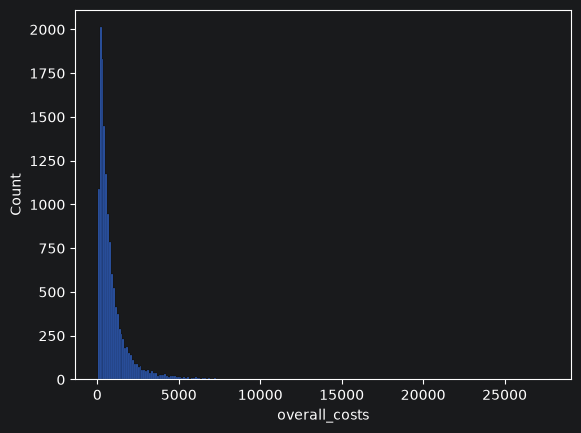

In [29]:
sns.histplot(hotels,x="overall_costs")

In [30]:
hotels['overall_costs'].describe()

count    13944.000000
mean       939.619263
std       1293.094636
min         24.000000
25%        280.000000
50%        546.000000
75%       1085.000000
max      27702.000000
Name: overall_costs, dtype: float64

<Axes: xlabel='hotel_per_room_usd', ylabel='Count'>

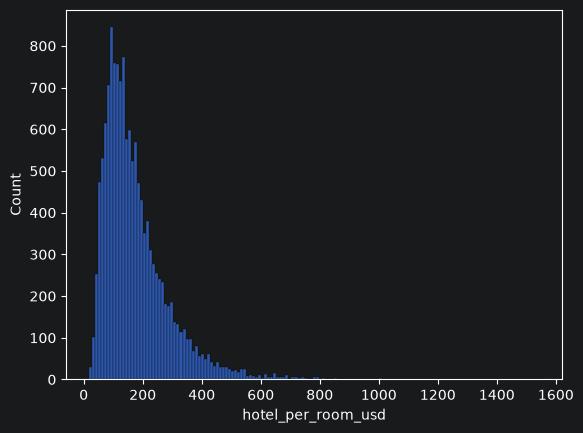

In [28]:
sns.histplot(hotels,x="hotel_per_room_usd")

<Axes: xlabel='checkin_weekday', ylabel='Count'>

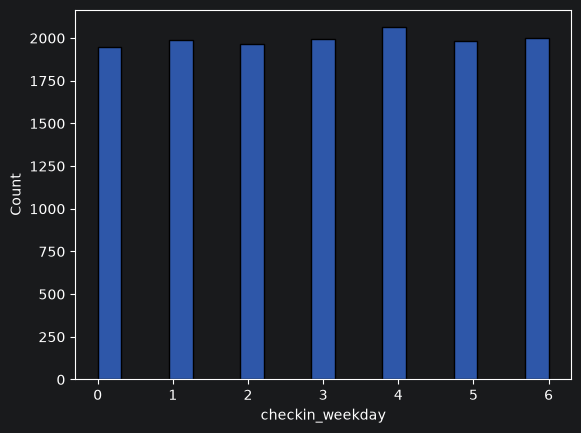

In [27]:
sns.histplot(hotels,x="checkin_weekday")

# Flights

In [40]:
flights.head()

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd,overall_costs
0,249521-67f87434c2c5448e932d66ada4f333b7,YOW,vancouver,YVR,1,True,2023-03-15 13:00:00,2023-03-18 13:00:00,1,Air Canada,49.195,-123.182,642.02,642.02
1,631970-609ad1b6defb47f29404e095ba4ebf2b,MEM,san antonio,SKF,1,True,2023-03-13 13:00:00,2023-03-16 13:00:00,0,United Airlines,29.529,-98.279,173.22,173.22
2,547862-0a5c5470c1a748ffbeb0725a3f9b2b33,EFD,austin,AUS,1,True,2023-03-13 10:00:00,2023-03-15 10:00:00,1,Southwest Airlines,30.194,-97.670,38.52,38.52
3,511805-b7a0f496d93940a7b64b7eb933a4355c,LAX,washington,DCA,1,True,2023-03-21 07:00:00,2023-03-27 07:00:00,0,JetBlue Airways,38.852,-77.037,711.62,711.62
4,564430-0444ddc505c3419b9ba2b7e7821e73fc,YHM,new york,JFK,1,True,2023-03-22 14:00:00,2023-03-26 14:00:00,0,Delta Air Lines,40.640,-73.779,105.95,105.95


<Axes: xlabel='base_fare_usd', ylabel='Count'>

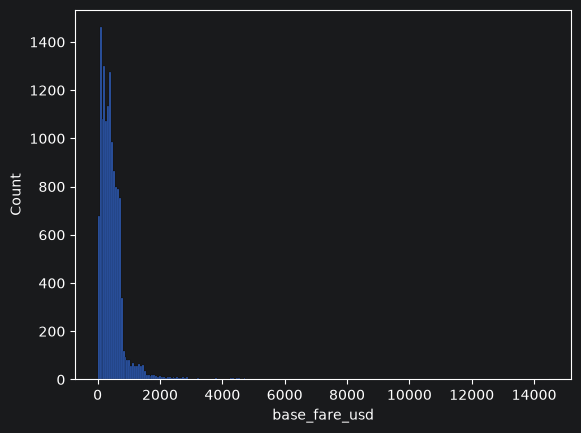

In [32]:
sns.histplot(flights, x="base_fare_usd")

In [33]:
flights['base_fare_usd'].describe()

count    13767.000000
mean       491.872990
std        678.151486
min          2.410000
25%        198.520000
50%        378.430000
75%        592.465000
max      14466.330000
Name: base_fare_usd, dtype: float64

In [35]:
#check for errors in seats:
flights['seats'].describe()
flights['seats'].value_counts()
#seems right

seats
1    11742
2     1487
3      384
4      123
5       18
6       11
7        1
8        1
Name: count, dtype: int64

In [39]:
#assumption: this price is per seat. For the overall cost:
flights['overall_costs']=flights['base_fare_usd']*flights['seats']

In [47]:
flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 13767 entries, 0 to 13766
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   trip_id                  13767 non-null  str    
 1   origin_airport           13767 non-null  str    
 2   destination              13767 non-null  str    
 3   destination_airport      13767 non-null  str    
 4   seats                    13767 non-null  int64  
 5   return_flight_booked     13767 non-null  bool   
 6   departure_time           13767 non-null  str    
 7   return_time              13172 non-null  str    
 8   checked_bags             13767 non-null  int64  
 9   trip_airline             13767 non-null  str    
 10  destination_airport_lat  13767 non-null  float64
 11  destination_airport_lon  13767 non-null  float64
 12  base_fare_usd            13767 non-null  float64
 13  overall_costs            13767 non-null  float64
dtypes: bool(1), float64(4), int64(2),

In [49]:
flights['checked_bags'].describe()
#bags per seat mean?

count    13767.000000
mean         0.585240
std          0.654654
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          8.000000
Name: checked_bags, dtype: float64

In [50]:
#right format
flights['departure_time']= pd.to_datetime(flights['departure_time'])
flights['return_time']= pd.to_datetime(flights['return_time'])

In [58]:
#are there timetravelers?
(((flights['return_time']-flights['departure_time']).dt.days)<=0).sum()

np.int64(72)

In [70]:
#who are they in the dataframe
print(flights[(flights['return_time'] - flights['departure_time']).dt.days <= 0])

Empty DataFrame
Columns: [trip_id, origin_airport, destination, destination_airport, seats, return_flight_booked, departure_time, return_time, checked_bags, trip_airline, destination_airport_lat, destination_airport_lon, base_fare_usd, overall_costs]
Index: []


In [69]:
#=> e.g. Row 2: PWM to JFK takes a little more than 1 hour, there is no time difference between those cities.
# departure time is always the same as arrival time here (tested it with == 0), so there is either a mistake in the departure time or arrival time or both. I am deleting the times, so there will be NaNs, because I want to keep the information, that there was a booked flight. maybe I am going to delete it later
condition = (flights['return_time'] - flights['departure_time']).dt.days <= 0
flights.loc[condition, ['return_time', 'departure_time']] = None

In [71]:
flights.head()

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd,overall_costs
0,249521-67f87434c2c5448e932d66ada4f333b7,YOW,vancouver,YVR,1,True,2023-03-15 13:00:00,2023-03-18 13:00:00,1,Air Canada,49.195,-123.182,642.02,642.02
1,631970-609ad1b6defb47f29404e095ba4ebf2b,MEM,san antonio,SKF,1,True,2023-03-13 13:00:00,2023-03-16 13:00:00,0,United Airlines,29.529,-98.279,173.22,173.22
2,547862-0a5c5470c1a748ffbeb0725a3f9b2b33,EFD,austin,AUS,1,True,2023-03-13 10:00:00,2023-03-15 10:00:00,1,Southwest Airlines,30.194,-97.670,38.52,38.52
3,511805-b7a0f496d93940a7b64b7eb933a4355c,LAX,washington,DCA,1,True,2023-03-21 07:00:00,2023-03-27 07:00:00,0,JetBlue Airways,38.852,-77.037,711.62,711.62
4,564430-0444ddc505c3419b9ba2b7e7821e73fc,YHM,new york,JFK,1,True,2023-03-22 14:00:00,2023-03-26 14:00:00,0,Delta Air Lines,40.640,-73.779,105.95,105.95


# Users